# Figures and Tables

## Dataframe display settings

If you want to change the display settings for pandas DataFrames, you can use the `pd.set_option()` function. For example, to display all columns in a DataFrame, you can set the `display.max_columns` option to `None` as follows:

In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Generate result summary in CSV format from log.md files

In [2]:
from log_to_csv import *
log_to_csv()

## Load csv files as pandas DataFrames

In [3]:
from analysis import *

dsns_file = '_dsns_whole.csv'
acasxu = pd.read_csv(f"./acasxu/acasxu{dsns_file}")
mnist4 = pd.read_csv(f"./mnist-256x4/mnist4{dsns_file}")
mnist_conv = pd.read_csv(f"./mnist-conv/mnistconv{dsns_file}")
cifar10 = pd.read_csv(f"./cifar10/cifar{dsns_file}")
gtsrb = pd.read_csv(f"./gtsrb/gtsrb{dsns_file}")

## Figure 3

Instance distribution shown in Figure 3 is generated by the following code. 

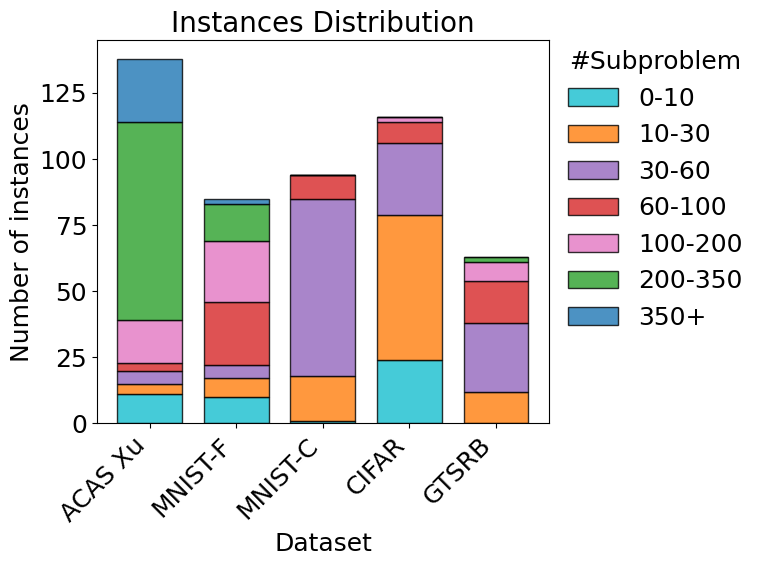

In [4]:
from draw_figures import *
fig = get_subproblems_distribution(acasxu, mnist4, mnist_conv, cifar10, gtsrb)
fig.show()

## Table III (RQ1)

**Comparison of RaVeN and SaBRe.**

Following scripts generate the latex style table shown in Table III and dataframe for visualization. 

Notation:
In dataframe, base corresponds to RaVeN and method corresponds to SaBRe.

In [5]:
method = 'DS_dual_Z'
acasxu_subproblems_num = get_subproblems_num(f"./acasxu/{method}_threshold", acasxu, acasxu=True)
mnist4_subproblems_num = get_subproblems_num(f"./mnist-256x4/{method}_threshold", mnist4)
mnist_conv_subproblems_num = get_subproblems_num(f"./mnist-conv/{method}_threshold", mnist_conv)
cifar10_subproblems_num = get_subproblems_num(f"./cifar10/{method}_threshold", cifar10)
gtsrb_subproblems_num = get_subproblems_num(f"./gtsrb/RS_dual_Z_threshold", gtsrb)
subproblems_num_dict = {
    'acasxu': acasxu_subproblems_num,
    'mnist4': mnist4_subproblems_num,
    'mnist-conv': mnist_conv_subproblems_num,
    'cifar10': cifar10_subproblems_num,
    'gtsrb': gtsrb_subproblems_num
}
analyze_with_base('DS_dual_Z', acasxu, mnist4, mnist_conv, cifar10, gtsrb, subproblems_num_dict)

\begin{tabular}{lccccccccc}
\toprule
\multirow{2}{*}{Dataset} & \multicolumn{2}{c}{$s^{\#}$} & & \multicolumn{2}{c}{$p^{\#}$} & & \multicolumn{2}{c}{$\Delta T$ (\%)} \\
\cmidrule(lr){2-3} \cmidrule(lr){5-6} \cmidrule(lr){8-9}
& RaVeN & SaBRe & & RaVeN & SaBRe & & RaVeN & SaBRe \\
\midrule
ACAS Xu & 42 & 67 && 1 & 151.7 && 0.79 & 20.50 \\
MNIST-F & 32 & 56 && 1 & 74.4 && 0.94 & 20.75 \\
MNIST-C & 23 & 27 && 1 & 32.3 && 9.56 & 66.07 \\
CIFAR & 10 & 23 && 1 & 25.5 && 2.40 & 46.79 \\
GTSRB & 9 & 33 && 1 & 38.8 && 2.22 & 39.09 \\
\bottomrule
\end{tabular}


$s^{\#}$       $p^{\#}$        $\Delta T$       
           RaVeN SaBRe    RaVeN  SaBRe      RaVeN  SaBRe
Dataset                                                 
ACAS Xu       42    67        1  151.7       0.79  20.50
MNIST-F       32    56        1   74.4       0.94  20.75
MNIST-C       23    27        1   32.3       9.56  66.07
CIFAR         10    23        1   25.5       2.40  46.79
GTSRB          9    33        1   38.8       2.22  39.09

## Table IV (RQ2)

**Comparison of individual splitting (ClasIS and DualIS) and relational splitting (SaBRe) methods.**

In [6]:
methods = ['NSInd', 'NS', 'DS_dual_Z']
get_table_Nsolved_timeRatio(acasxu, mnist4, mnist_conv, cifar10, gtsrb, methods)

\begin{tabular}{lccccccccccccccc}
\toprule
\multirow{2}{*}{Method} & \multicolumn{3}{c}{ACAS Xu} & \multicolumn{3}{c}{MNIST-F} & \multicolumn{3}{c}{MNIST-C} & \multicolumn{3}{c}{CIFAR} & \multicolumn{3}{c}{GTSRB} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13} \cmidrule(lr){14-16}
& $s^{\#}$ & $p^{\#}$ & $\Delta T$ & $s^{\#}$ & $p^{\#}$ & $\Delta T$ & $s^{\#}$ & $p^{\#}$ & $\Delta T$ & $s^{\#}$ & $p^{\#}$ & $\Delta T$ & $s^{\#}$ & $p^{\#}$ & $\Delta T$ \\
\midrule
ClasIS & 12 & 133.9 & 85.95 & 24 & 124.0 & 75.26 & 6 & 32.0 & 89.15 & 28 & 21.6 & 70.62 & 24 & 50.9 & 60.95 \\
DualIS & 9 & 120.5 & 88.14 & 27 & 119.9 & 71.58 & 8 & 33.3 & 90.56 & 31 & 21.4 & 67.30 & 23 & 58.0 & 66.83 \\
SaBRe & 67 & 83.4 & 26.02 & 56 & 53.1 & 24.78 & 27 & 27.5 & 70.45 & 23 & 28.3 & 73.96 & 33 & 39.6 & 50.98 \\
\bottomrule
\end{tabular}


ACAS Xu                      MNIST-F                      MNIST-C  \
       $s^{\#}$ $p^{\#}$ $\Delta T$ $s^{\#}$ $p^{\#}$ $\Delta T$ $s^{\#}$   
Method                                                                      
ClasIS       12    133.9      85.95       24    124.0      75.26        6   
DualIS        9    120.5      88.14       27    119.9      71.58        8   
SaBRe        67     83.4      26.02       56     53.1      24.78       27   

                              CIFAR                        GTSRB           \
       $p^{\#}$ $\Delta T$ $s^{\#}$ $p^{\#}$ $\Delta T$ $s^{\#}$ $p^{\#}$   
Method                                                                      
ClasIS     32.0      89.15       28     21.6      70.62       24     50.9   
DualIS     33.3      90.56       31     21.4      67.30       23     58.0   
SaBRe      27.5      70.45       23     28.3      73.96       33     39.6   

                   
       $\Delta T$  
Method             
ClasIS      60.95  
DualIS      66.83  
SaBRe       50.98

## Figure 4 (RQ2)

Boxplots in Figure 4 are generated by the following script.

/Users/kotafukuda/Documents/Project_univ/ds_open/evaluation/draw_figures.py:470: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/kotafukuda/Documents/Project_univ/ds_open/evaluation/draw_figures.py:470: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/kotafukuda/Documents/Project_univ/ds_open/evaluation/draw_figures.py:470: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/kotafukuda/Documents/Project_univ/ds_open/evaluation/draw_figures.py:470: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/kotafukuda/Documents/Project_univ/ds_open/evaluation/draw_figures.py:470: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


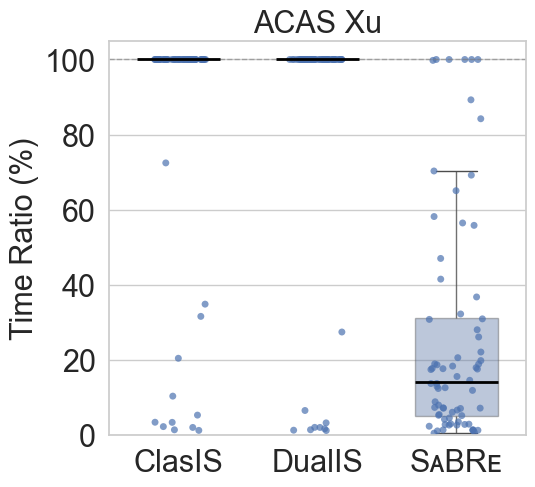

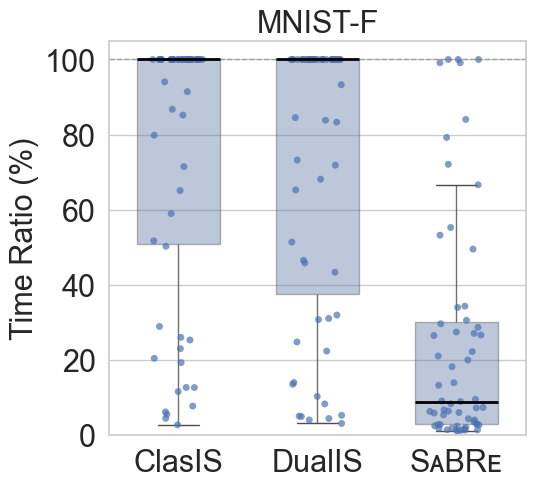

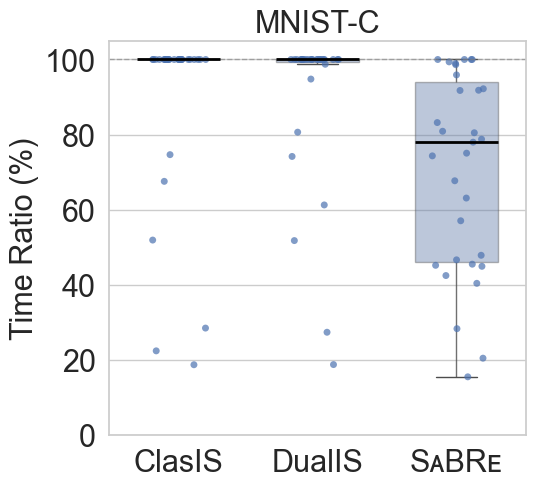

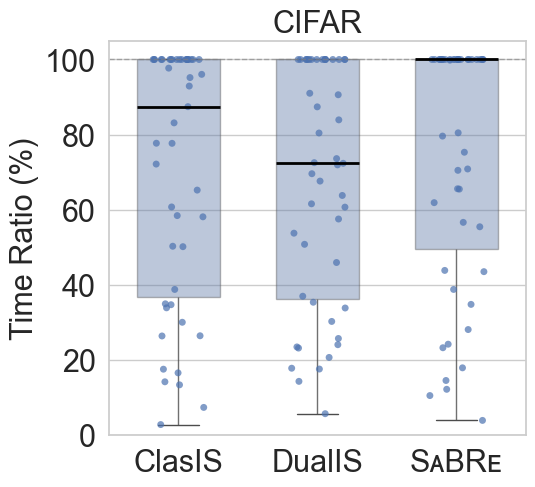

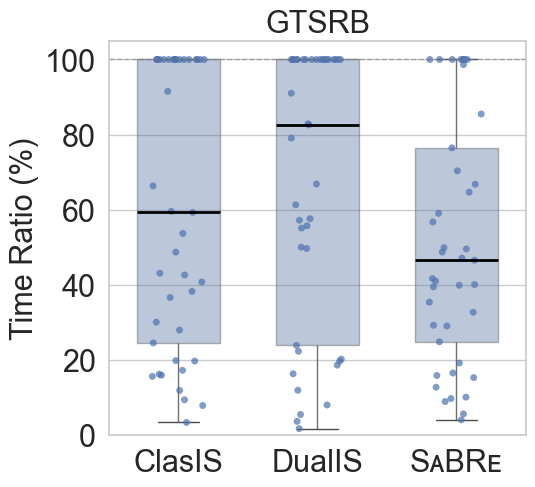

In [7]:
from draw_figures import *
draw_boxplot()

## Figure 5 (RQ2)

Bar chart of solved instances in Figure 5 is generated by the following script.

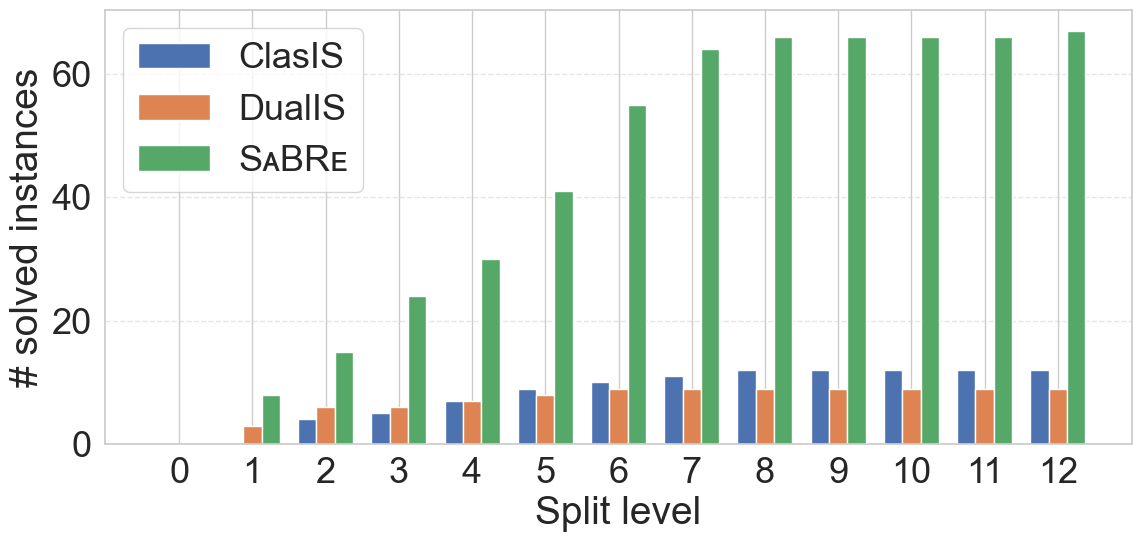

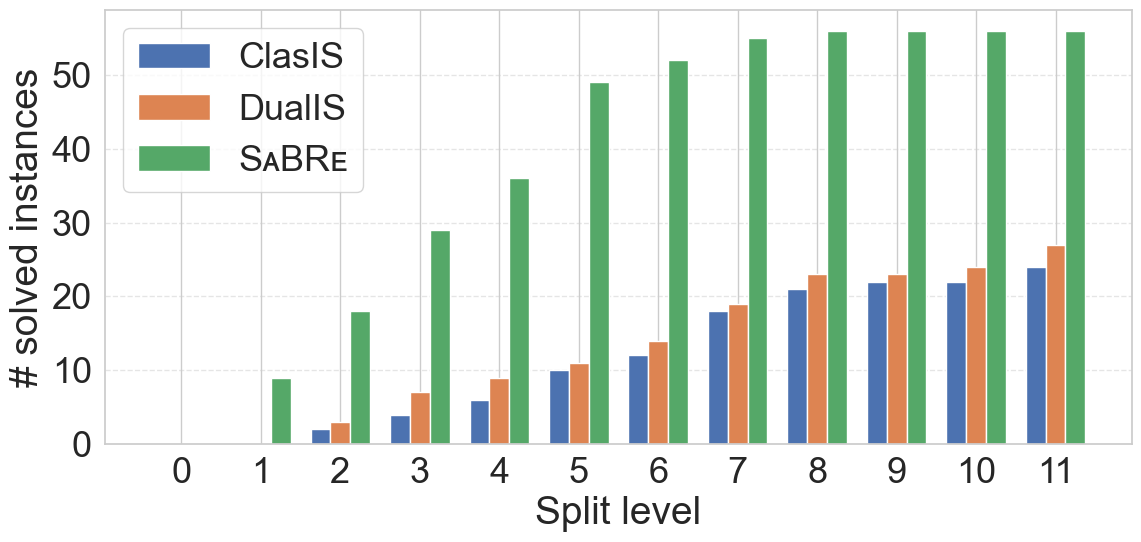

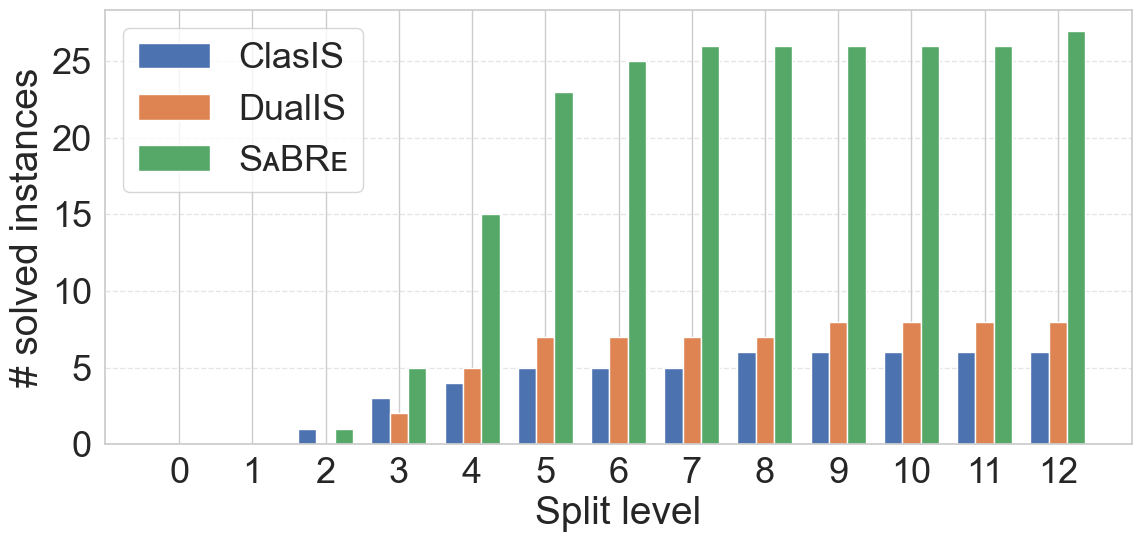

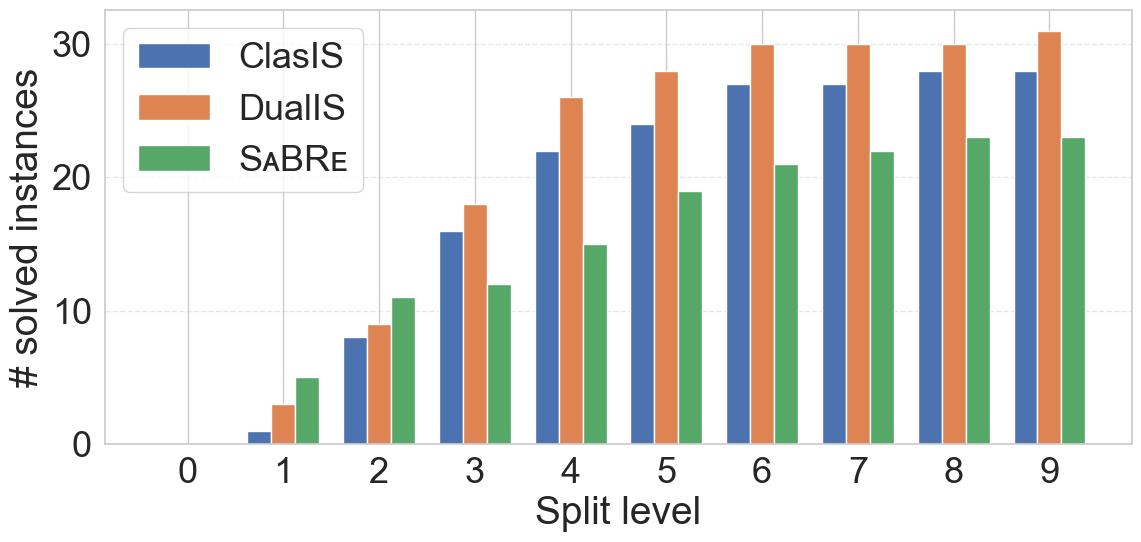

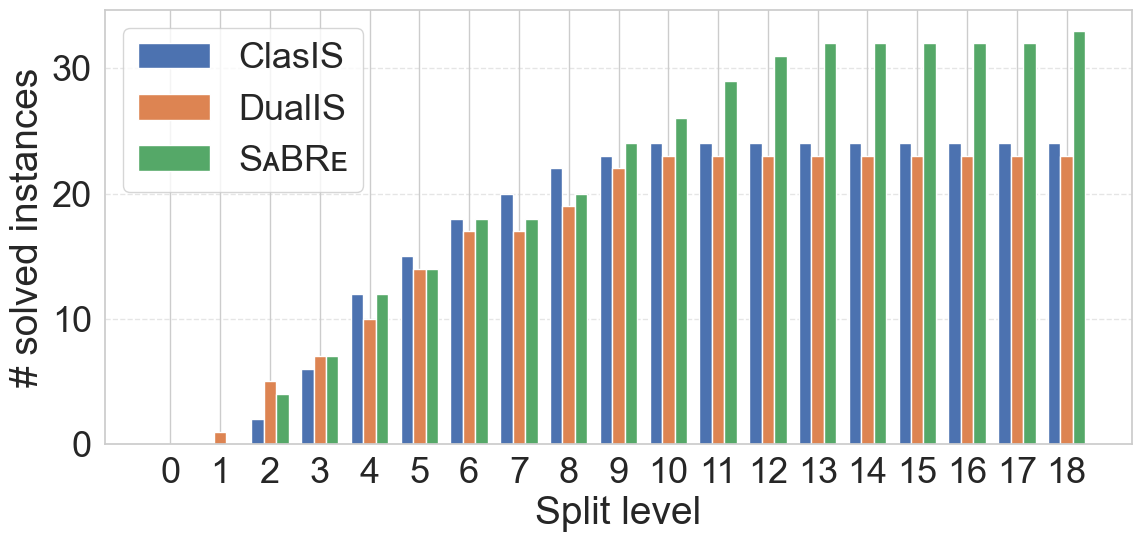

In [8]:
from line_graph import *
plot_bar_solved_all(filter_d=None)

## Table V (RQ2)

Comparison on different perturbation distances ($\epsilon = 1/256, 2/256, 3/256$) in CIFAR. Each $d$ in the following latex table and dataframe corresponds to $\epsilon = d/256$.

In [9]:
get_solved_num_and_timeratio_on_d(cifar10, "cifar10")

\begin{tabular}{lccccccccc}
\toprule
\multirow{2}{*}{Method} & \multicolumn{2}{c}{$d=1$} & \multicolumn{2}{c}{$d=2$} & \multicolumn{2}{c}{$d=3$} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7}
& \solved & \subproblems & \deltaTime & \solved & \subproblems & \deltaTime & \solved & \subproblems & \deltaTime \\
\midrule
ClasIS & 16 & 22.1 & 56.49 & 8 & 22.6 & 77.34 & 4 & 19.3 & 93.54 \\
DualIS & 16 & 22.3 & 56.71 & 11 & 20.8 & 67.03 & 4 & 21.0 & 90.72 \\
SaBRe & 5 & 41.2 & 87.03 & 10 & 22.6 & 64.55 & 8 & 15.3 & 74.48 \\
\bottomrule
\end{tabular}


,method,d1_solved,d1_subproblems,d1_deltaTime,d2_solved,d2_subproblems,d2_deltaTime,d3_solved,d3_subproblems,d3_deltaTime
0,ClasIS,16,22.1,56.49,8,22.6,77.34,4,19.3,93.54
1,DualIS,16,22.3,56.71,11,20.8,67.03,4,21.0,90.72
2,SaBRe,5,41.2,87.03,10,22.6,64.55,8,15.3,74.48


## Table VI and Table VII (RQ3)

Comparison on different number of dimensional-perturbation analysis. Each $p^{\%}$ in the following latex table and dataframe corresponds to the ratio indicating the percentage of perturbed dimensions.

In [10]:
from analysis_dp import *
dp_tables()

Comparison tools selected by key 1: IS_dual_ind, IS_dual, RS_dual_Z


```latex
\begin{table}
\centering
\resizebox{\linewidth}{!}{
\begin{tabular}{lcccccccccccc}
\toprule
\multirow{2}{*}{Method} & \multicolumn{3}{c}{$p^{\%}=1$} & \multicolumn{3}{c}{$p^{\%}=0.5$} & \multicolumn{3}{c}{$p^{\%}=0.25$} & \multicolumn{3}{c}{$p^{\%}=0.125$} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13}
& $s^{\#}$ & $p^{\#}$ & $\Delta T$ & $s^{\#}$ & $p^{\#}$ & $\Delta T$ & $s^{\#}$ & $p^{\#}$ & $\Delta T$ & $s^{\#}$ & $p^{\#}$ & $\Delta T$ \\
\midrule
ClasIS & 15 & 144.4 & 58.72 & 20 & 164.8 & 52.62 & 28 & 125.6 & 37.71 & 39 & 31.6 & 9.56 \\
DualIS & 17 & 113.4 & 49.73 & 18 & 152.5 & 53.28 & 28 & 121.6 & 34.91 & 40 & 31.6 & 9.24 \\
SaBRe & 24 & 75.7 & 30.01 & 35 & 78.0 & 27.00 & 40 & 38.7 & 11.02 & 41 & 16.6 & 6.89 \\
\bottomrule
\end{tabular}
}
\end{table}

```

```latex
\begin{table}
\centering
\resizebox{\linewidth}{!}{
\begin{tabular}{lcccc}
\toprule
& $p^{\%}=1$ & $p^{\%}=0.5$ & $p^{\%}=0.25$ & $p^{\%}=0.125$ \\
\midrule
Unstable ReLUs & 406.2 / 2068.0 & 83.4 / 2068.0 & 36.0 / 2068.0 & 17.2 / 2068.0 \\
\bottomrule
\end{tabular}
}
\end{table}

```

p^%=1                p^%=0.5                p^%=0.25                 \
         s^#    p^# Delta T     s^#    p^# Delta T      s^#    p^# Delta T   
Method                                                                       
ClasIS    15  144.4   58.72      20  164.8   52.62       28  125.6   37.71   
DualIS    17  113.4   49.73      18  152.5   53.28       28  121.6   34.91   
SaBRe     24   75.7   30.01      35   78.0   27.00       40   38.7   11.02   

       p^%=0.125                
             s^#   p^# Delta T  
Method                          
ClasIS        39  31.6    9.56  
DualIS        40  31.6    9.24  
SaBRe         41  16.6    6.89

,p^%=1,p^%=0.5,p^%=0.25,p^%=0.125
,,,,
Metric,,,,
Unstable ReLUs,406.2 / 2068.0,83.4 / 2068.0,36.0 / 2068.0,17.2 / 2068.0


## Table VIII (RQ4)

Comparison of relational neuron selection strategy on random (RandRS) and dual (SaBRe) selection methods.

In [11]:
methods = ['DS_random_Z', 'DS_dual_Z']
get_table_Nsolved_timeRatio(acasxu, mnist4, mnist_conv, cifar10, gtsrb, methods)

\begin{tabular}{lccccccccccccccc}
\toprule
\multirow{2}{*}{Method} & \multicolumn{3}{c}{ACAS Xu} & \multicolumn{3}{c}{MNIST-F} & \multicolumn{3}{c}{MNIST-C} & \multicolumn{3}{c}{CIFAR} & \multicolumn{3}{c}{GTSRB} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13} \cmidrule(lr){14-16}
& $s^{\#}$ & $p^{\#}$ & $\Delta T$ & $s^{\#}$ & $p^{\#}$ & $\Delta T$ & $s^{\#}$ & $p^{\#}$ & $\Delta T$ & $s^{\#}$ & $p^{\#}$ & $\Delta T$ & $s^{\#}$ & $p^{\#}$ & $\Delta T$ \\
\midrule
RandRS & 44 & 199.2 & 59.35 & 43 & 114.0 & 47.58 & 11 & 38.7 & 89.06 & 8 & 24.4 & 78.33 & 9 & 92.5 & 86.60 \\
SaBRe & 67 & 100.8 & 32.58 & 56 & 59.4 & 26.03 & 27 & 28.2 & 67.28 & 23 & 18.0 & 57.80 & 33 & 35.5 & 39.09 \\
\bottomrule
\end{tabular}


ACAS Xu                      MNIST-F                      MNIST-C  \
       $s^{\#}$ $p^{\#}$ $\Delta T$ $s^{\#}$ $p^{\#}$ $\Delta T$ $s^{\#}$   
Method                                                                      
RandRS       44    199.2      59.35       43    114.0      47.58       11   
SaBRe        67    100.8      32.58       56     59.4      26.03       27   

                              CIFAR                        GTSRB           \
       $p^{\#}$ $\Delta T$ $s^{\#}$ $p^{\#}$ $\Delta T$ $s^{\#}$ $p^{\#}$   
Method                                                                      
RandRS     38.7      89.06        8     24.4      78.33        9     92.5   
SaBRe      28.2      67.28       23     18.0      57.80       33     35.5   

                   
       $\Delta T$  
Method             
RandRS      86.60  
SaBRe       39.09

## Figure 4 (RQ5)

Pairwise comparison plots for maximum verifiable distance in Figure 4 are generated by the following script. 

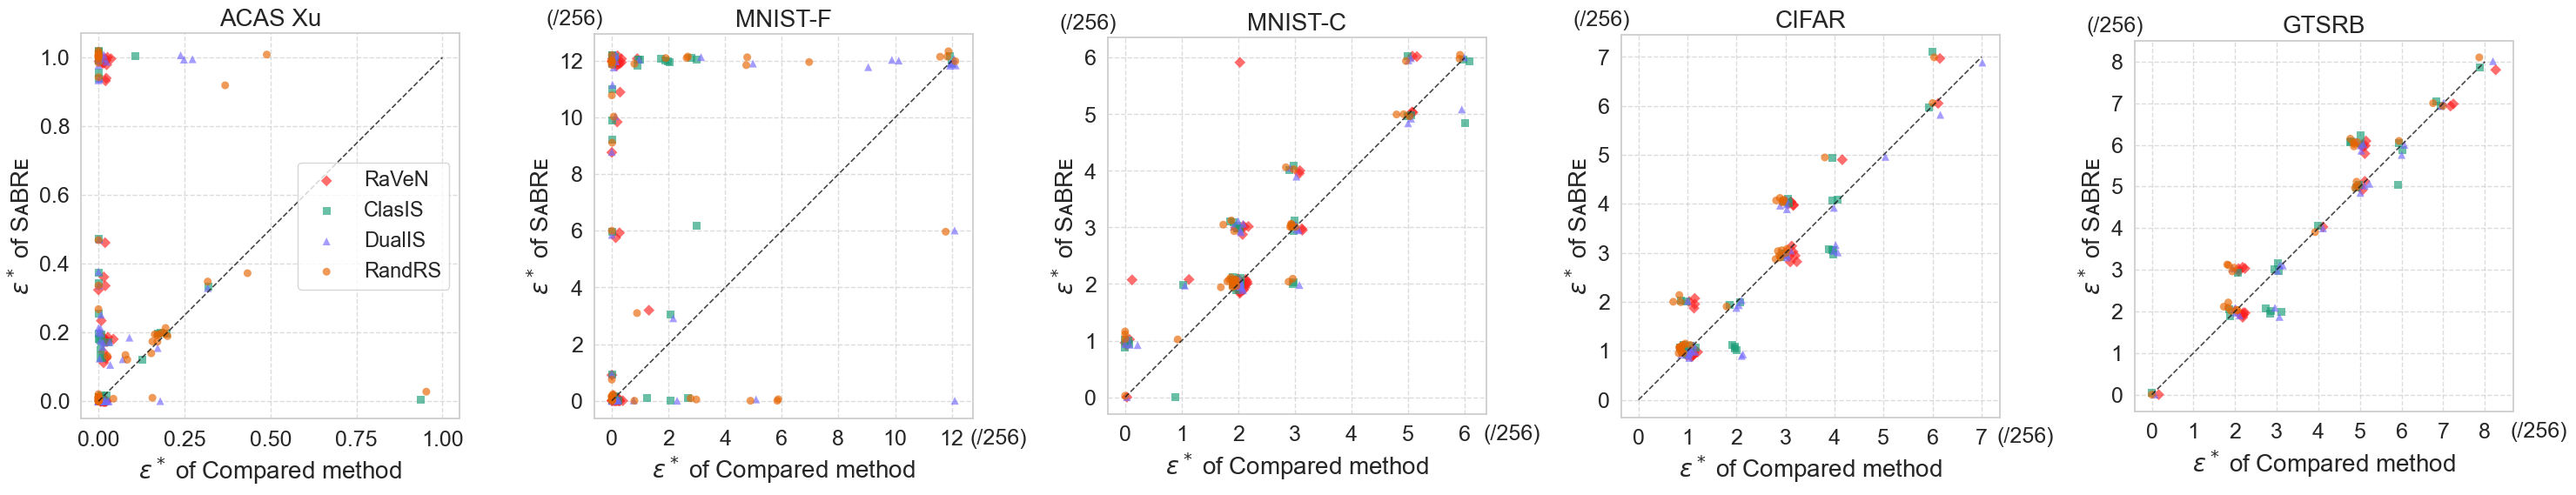

In [12]:
from binary_search import *
plot_epsilon_ratio_boxplot_all(cap=10, log_scale=False)

## RQ5 (Figure 5)

Statistical summary of binary search results in Figure 5 is generated by the following script. Each value represents Cohen's d value for row method against column method. 

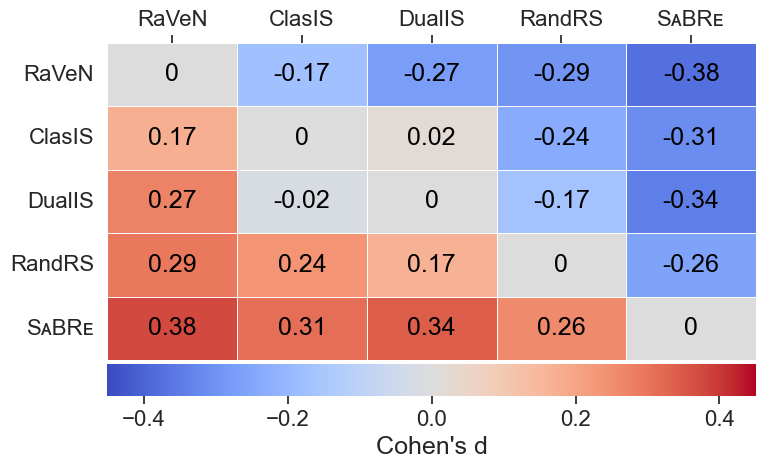

In [13]:
from binary_search import *
statistical_analysis_merge()